In [1]:
mkdir -p ~/.kaggle && echo KGAT_e731936d7f813b8f657dd0c09de4f809 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [2]:
#!/bin/bash
!kaggle datasets download fedesoriano/traffic-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/traffic-prediction-dataset
License(s): copyright-authors
100% 277k/277k [00:00<00:00, 467kB/s]



In [3]:
!mkdir traffic_pred_raw
!unzip -q traffic-prediction-dataset.zip -d traffic_pred_raw

In [4]:
#импорт всех необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.fftpack import dct
from sklearn.linear_model import Ridge
import time
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.ensemble import RandomForestRegressor
from joblib import Parallel, delayed
import lightgbm as lgb
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, ParameterGrid
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler


file_path = '/content/traffic_pred_raw/traffic.csv'
df = pd.read_csv(file_path)
df['DateTime'] = pd.to_datetime(df['DateTime'])

#оставляем строки только для Junction 1
df_filtered = df[df['Junction'] == 1]
df_sorted = df_filtered.sort_values(by='DateTime')
df_final = df_sorted.set_index('DateTime')
traffic_series = df_final['Vehicles']

/tmp/ipykernel_1609/3574961744.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  traffic_series = traffic_series.asfreq('H')


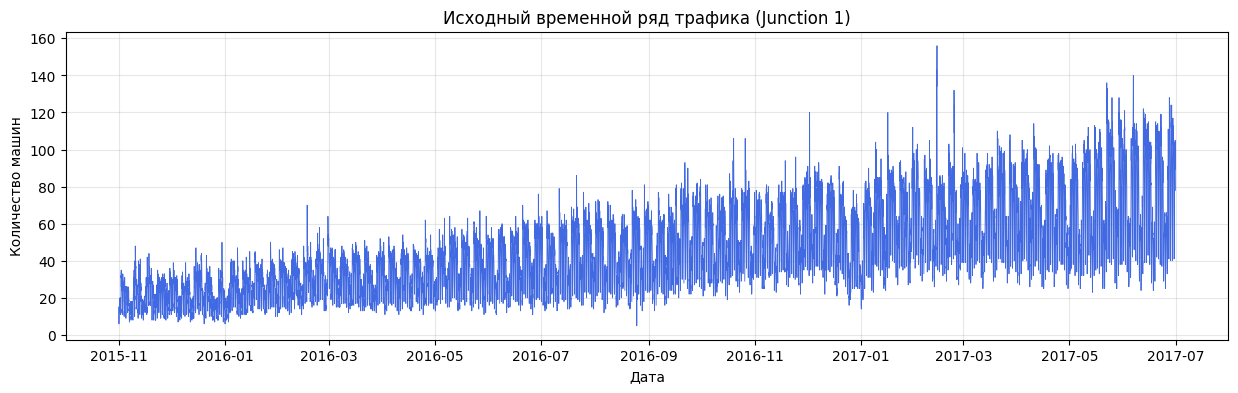

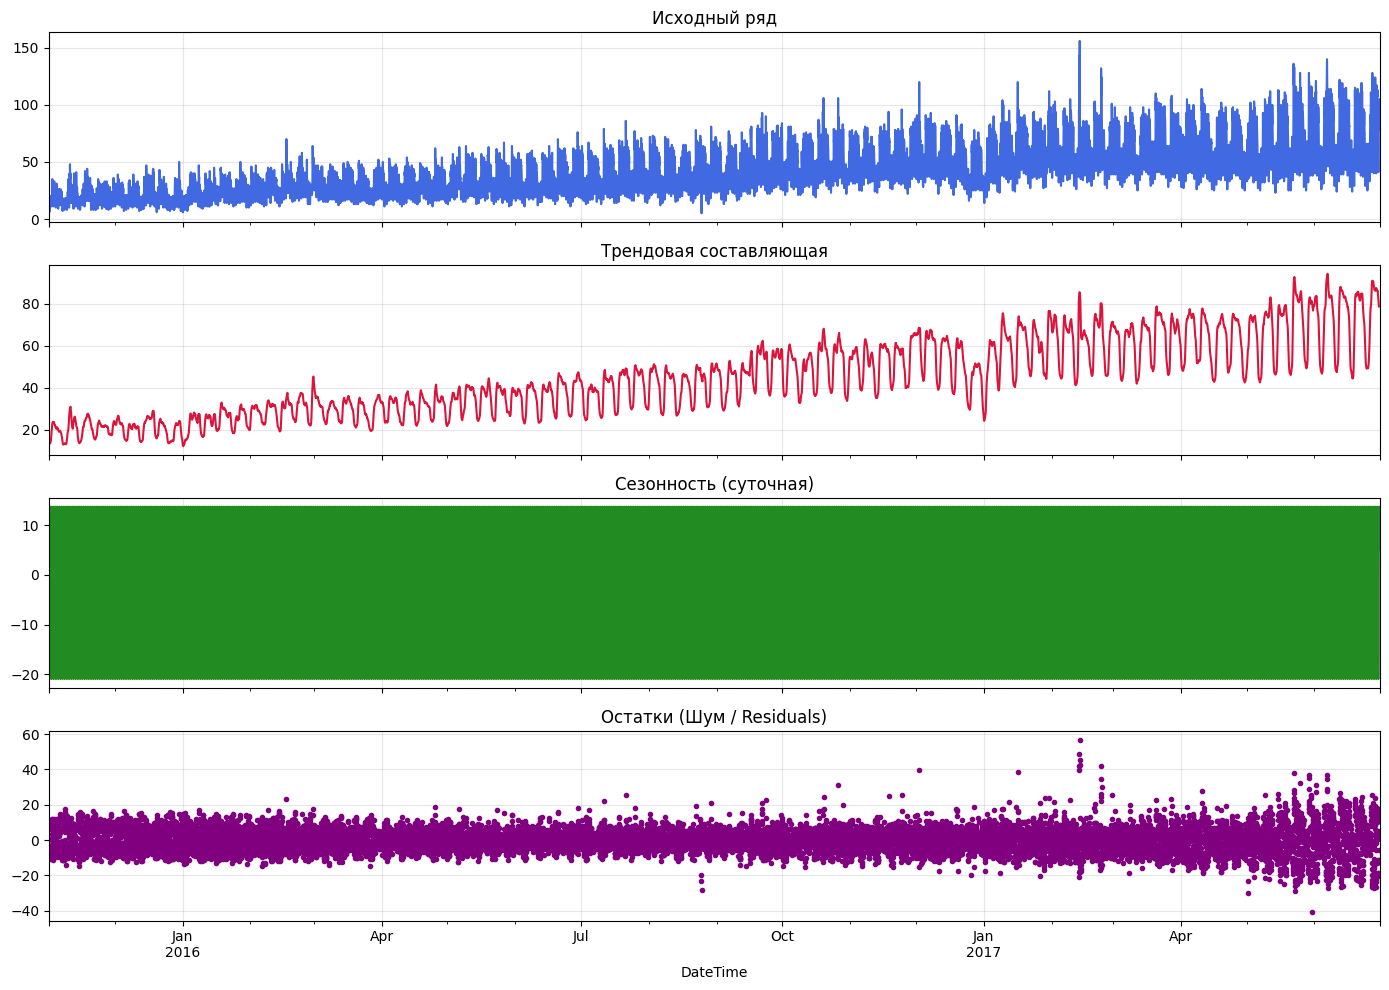

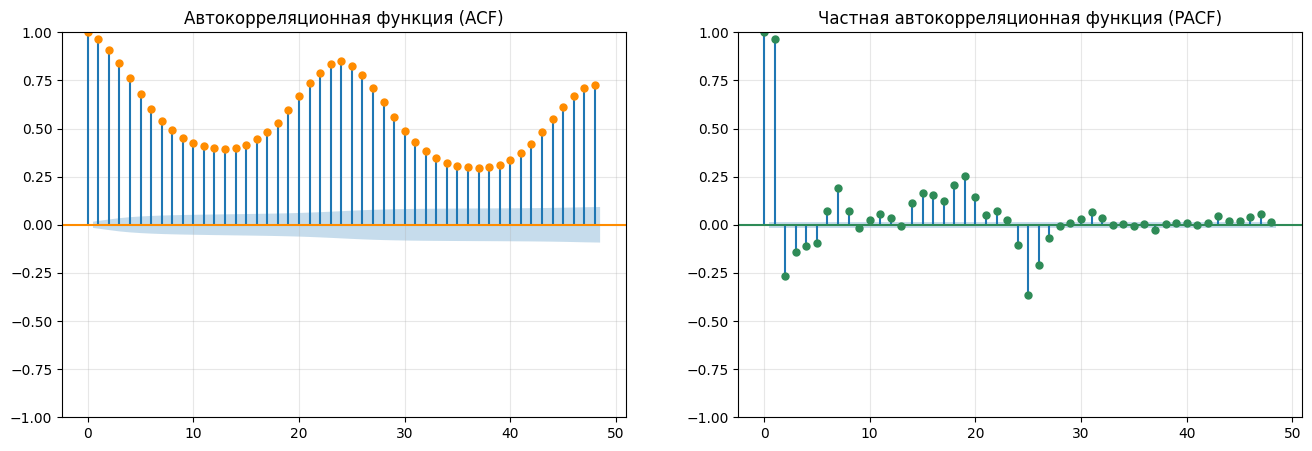

In [5]:

traffic_series = traffic_series.asfreq('H')

#График исходного временного ряда
plt.figure(figsize=(15, 4))
plt.plot(traffic_series, color='royalblue', linewidth=0.6)
plt.title('Исходный временной ряд трафика (Junction 1)')
plt.xlabel('Дата')
plt.ylabel('Количество машин')
plt.grid(True, alpha=0.3)
plt.show()

#Декомпозиция (период 24 часа)
decomposition = seasonal_decompose(traffic_series, model='additive', period=24)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='royalblue', title='Исходный ряд')
decomposition.trend.plot(ax=ax2, color='crimson', title='Трендовая составляющая')
decomposition.seasonal.plot(ax=ax3, color='forestgreen', title='Сезонность (суточная)')
decomposition.resid.plot(ax=ax4, color='purple', style='.', title='Остатки (Шум / Residuals)')

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#ACF и PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(traffic_series, lags=48, ax=axes[0], color='darkorange')
axes[0].set_title('Автокорреляционная функция (ACF)')
axes[0].grid(True, alpha=0.3)
plot_pacf(traffic_series, lags=48, ax=axes[1], color='seagreen', method='ywm')
axes[1].set_title('Частная автокорреляционная функция (PACF)')
axes[1].grid(True, alpha=0.3)
plt.show()

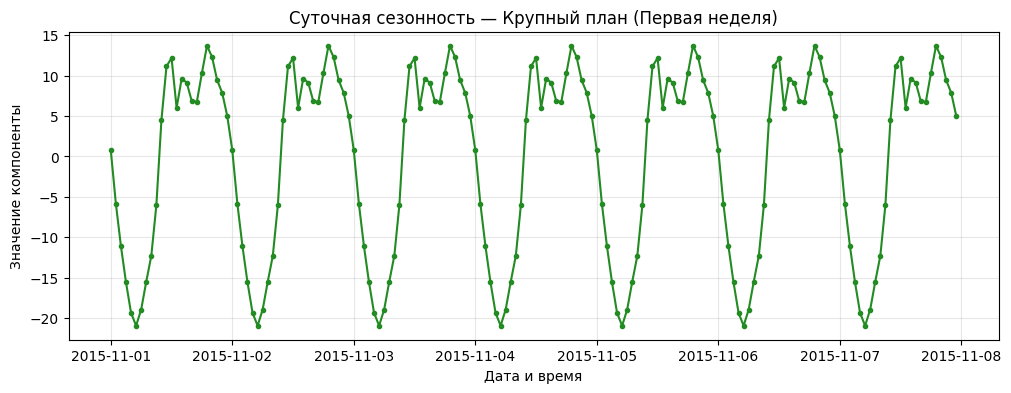

In [6]:
#Смотрим крупным планом
plt.figure(figsize=(12, 4))
plt.plot(decomposition.seasonal.iloc[:168], color='forestgreen', marker='o', markersize=3)
plt.title('Суточная сезонность — Крупный план (Первая неделя)')
plt.xlabel('Дата и время')
plt.ylabel('Значение компоненты')
plt.grid(True, alpha=0.3)
plt.show()

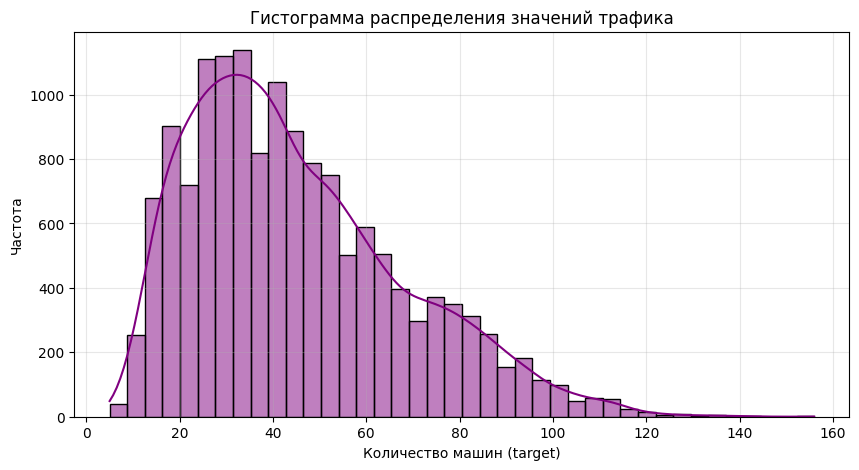

In [7]:
#распределение значений target
plt.figure(figsize=(10, 5))
sns.histplot(traffic_series, kde=True, color='purple', bins=40)
plt.title('Гистограмма распределения значений трафика')
plt.xlabel('Количество машин (target)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
print("\n[1] Тест Дики-Фуллера на стационарность:")
adf_result = adfuller(traffic_series)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("=> Ряд стационарен (p < 0.05). Нулевая гипотеза отвергнута.")
else:
    print("=> Ряд нестационарен (p >= 0.05). Есть тренд или меняющаяся дисперсия.")

print("\n[2] Тест Шапиро-Уилка на нормальность остатков (выборка):")
residuals = decomposition.resid.dropna()
res_sample = residuals.sample(4000, random_state=42) #частичное из-за ограничений
shapiro_stat, shapiro_p = stats.shapiro(res_sample)
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("=> Распределение остатков отличается от нормального (p < 0.05).")
else:
    print("=> Распределение остатков визуально близко к нормальному (p >= 0.05).")

print("\n[3] Тест Льюнга-Бокса на автокорреляцию остатков:")
lb_result = acorr_ljungbox(residuals, lags=[24], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"Ljung-Box p-value (на лаге 24): {lb_p:.4f}")
if lb_p < 0.05:
    print("=> В остатках ЕСТЬ взаимосвязь/автокорреляция. Модель декомпозиции вынула не все зависимости.")
else:
    print("=> Остатки похожи на чистый белый шум (автокорреляции нет).")


[1] Тест Дики-Фуллера на стационарность:
ADF Statistic: -7.1481
p-value: 0.0000
=> Ряд стационарен (p < 0.05). Нулевая гипотеза отвергнута.

[2] Тест Шапиро-Уилка на нормальность остатков (выборка):
Shapiro-Wilk Statistic: 0.9746
p-value: 0.0000
=> Распределение остатков отличается от нормального (p < 0.05).

[3] Тест Льюнга-Бокса на автокорреляцию остатков:
Ljung-Box p-value (на лаге 24): 0.0000
=> В остатках ЕСТЬ взаимосвязь/автокорреляция. Модель декомпозиции вынула не все зависимости.


In [9]:
df_feats = pd.DataFrame(index=traffic_series.index)
df_feats['target'] = traffic_series.values

#сдвинем на 1 шаг назад (чтобы не было утечки)
x_hist = df_feats['target'].shift(1)

#Простые лаги
for lag in range(1, 31):
    df_feats[f'lag_{lag}'] = df_feats['target'].shift(lag)

#Сезонные лаги
for s in [24, 48, 72]:
    df_feats[f'seasonal_lag_{s}'] = df_feats['target'].shift(s)

#Дифференциальные лаги
df_feats['diff_1'] = x_hist.diff(1)
df_feats['diff_2'] = x_hist.diff(1).diff(1)

#Логарифмические лаги
for lag in range(1, 11):
    df_feats[f'log_lag_{lag}'] = np.log1p(df_feats['target'].shift(lag))


#скользящие статистики
windows = [3, 5, 7, 14, 21, 30]
for w in windows:
    rolling = x_hist.rolling(window=w)

    df_feats[f'roll_mean_{w}'] = rolling.mean()
    df_feats[f'roll_median_{w}'] = rolling.median()
    df_feats[f'roll_std_{w}'] = rolling.std()
    df_feats[f'roll_min_{w}'] = rolling.min()
    df_feats[f'roll_max_{w}'] = rolling.max()
    df_feats[f'roll_range_{w}'] = df_feats[f'roll_max_{w}'] - df_feats[f'roll_min_{w}']
    df_feats[f'roll_var_{w}'] = rolling.var()
    df_feats[f'roll_skew_{w}'] = rolling.skew()

    if w > 3:
        df_feats[f'roll_kurt_{w}'] = rolling.kurt()

    q25 = rolling.quantile(0.25)
    q75 = rolling.quantile(0.75)
    df_feats[f'roll_q25_{w}'] = q25
    df_feats[f'roll_q75_{w}'] = q75
    df_feats[f'roll_iqr_{w}'] = q75 - q25

print(f"Размер итоговой матрицы: {df_feats.shape}")

Размер итоговой матрицы: (14592, 117)


/tmp/ipykernel_1609/272570013.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feats[f'roll_skew_{w}'] = rolling.skew()
/tmp/ipykernel_1609/272570013.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feats[f'roll_kurt_{w}'] = rolling.kurt()
/tmp/ipykernel_1609/272570013.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fra

In [10]:

alphas = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
ema_features = {}

for a in alphas:
    #Простое EMA
    ema1 = x_hist.ewm(alpha=a, adjust=False).mean()
    ema_features[f'ema_alpha_{a}'] = ema1

    #Двойное EMA (DEMA)
    ema2 = ema1.ewm(alpha=a, adjust=False).mean()
    dema = 2 * ema1 - ema2
    ema_features[f'dema_alpha_{a}'] = dema

    #Тройное EMA (TEMA)
    ema3 = ema2.ewm(alpha=a, adjust=False).mean()
    tema = 3 * ema1 - 3 * ema2 + ema3
    ema_features[f'tema_alpha_{a}'] = tema

#Адаптивное EMA
def calculate_kama(series, period=10, fast_span=2, slow_span=30):

    change = series.diff(period).abs()
    volatility = series.diff().abs().rolling(window=period).sum()
    er = change / volatility
    er = er.fillna(0)
    fast_sc = 2 / (fast_span + 1)
    slow_sc = 2 / (slow_span + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    kama = np.zeros(len(series))
    kama[0] = series.iloc[0] if not pd.isna(series.iloc[0]) else 0
    for i in range(1, len(series)):
        if pd.isna(series.iloc[i]):
            kama[i] = kama[i-1]
        else:
            kama[i] = kama[i-1] + sc.iloc[i] * (series.iloc[i] - kama[i-1])

    return pd.Series(kama, index=series.index)

ema_features['adaptive_ema'] = calculate_kama(x_hist.fillna(0))

df_ema = pd.DataFrame(ema_features, index=df_feats.index)
df_feats = pd.concat([df_feats, df_ema], axis=1)

print(f"Новый размер итоговой матрицы: {df_feats.shape}")

Новый размер итоговой матрицы: (14592, 136)


In [11]:
tech_features = {}
s = x_hist.copy()

for n in [3, 6, 12, 24]:
    tech_features[f'momentum_{n}'] = s - s.shift(n)

#ROC
for n in [3, 6, 12, 24]:
    tech_features[f'roc_{n}'] = ((s - s.shift(n)) / (s.shift(n) + 1e-5)) * 100

#RSI
def calculate_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / (loss + 1e-5)
    return 100 - (100 / (1 + rs))

for p in [14, 21, 30]:
    tech_features[f'rsi_{p}'] = calculate_rsi(s, p)

#Stochastic Oscillator
low_14 = s.rolling(window=14).min()
high_14 = s.rolling(window=14).max()
tech_features['stoch_k'] = ((s - low_14) / (high_14 - low_14 + 1e-5)) * 100
tech_features['stoch_d'] = pd.Series(tech_features['stoch_k']).rolling(window=3).mean()

#Williams
tech_features['williams_r'] = ((high_14 - s) / (high_14 - low_14 + 1e-5)) * -100

#MACD
ema12 = s.ewm(span=12, adjust=False).mean()
ema26 = s.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
signal_line = macd_line.ewm(span=9, adjust=False).mean()

tech_features['macd_line'] = macd_line
tech_features['macd_signal'] = signal_line
tech_features['macd_histogram'] = macd_line - signal_line

#Bollinger Bands
bb_mean = s.rolling(window=20).mean()
bb_std = s.rolling(window=20).std()

tech_features['bb_middle'] = bb_mean
tech_features['bb_high'] = bb_mean + (2 * bb_std)
tech_features['bb_low'] = bb_mean - (2 * bb_std)
tech_features['bb_width'] = (tech_features['bb_high'] - tech_features['bb_low']) / (bb_mean + 1e-5)
tech_features['bb_position'] = (s - tech_features['bb_low']) / (tech_features['bb_high'] - tech_features['bb_low'] + 1e-5)

#Volatility Ratio
tech_features['volatility_ratio'] = s.rolling(window=5).std() / (s.rolling(window=40).std() + 1e-5)

df_tech = pd.DataFrame(tech_features, index=df_feats.index)
df_feats = pd.concat([df_feats, df_tech], axis=1)

print(f"Текущий размер итоговой матрицы: {df_feats.shape}")

Текущий размер итоговой матрицы: (14592, 159)


In [12]:
if not isinstance(df_feats.index, pd.DatetimeIndex):
    df_feats.index = pd.to_datetime(df_feats.index)

time_features = {}
idx = df_feats.index

#Базовые календарные признаки
time_features['hour'] = idx.hour
time_features['dayofmonth'] = idx.day
time_features['quarter'] = idx.quarter
time_features['dayofyear'] = idx.dayofyear
time_features['weekofyear'] = idx.isocalendar().week.astype(int)

#Циклические кодировки (sin / cos)
time_features['sin_hour'] = np.sin(2 * np.pi * idx.hour / 24)
time_features['cos_hour'] = np.cos(2 * np.pi * idx.hour / 24)
time_features['sin_dayofweek'] = np.sin(2 * np.pi * idx.dayofweek / 7)
time_features['cos_dayofweek'] = np.cos(2 * np.pi * idx.dayofweek / 7)
time_features['sin_month'] = np.sin(2 * np.pi * (idx.month - 1) / 12)
time_features['cos_month'] = np.cos(2 * np.pi * (idx.month - 1) / 12)
time_features['sin_dayofyear'] = np.sin(2 * np.pi * (idx.dayofyear - 1) / 365)
time_features['cos_dayofyear'] = np.cos(2 * np.pi * (idx.dayofyear - 1) / 365)

#Бинарные признаки
time_features['is_weekend'] = idx.dayofweek.isin([5, 6]).astype(int)
time_features['is_month_start'] = idx.is_month_start.astype(int)
time_features['is_month_end'] = idx.is_month_end.astype(int)

#американские федеральные праздники
cal = USFederalHolidayCalendar()
us_holidays = cal.holidays(start=idx.min(), end=idx.max())

time_features['is_holiday'] = idx.normalize().isin(us_holidays).astype(int)
df_time_base = pd.DataFrame(time_features, index=idx)

#One-Hot Encoding для dayofweek и month
ohe_day = pd.get_dummies(idx.dayofweek, prefix='dayofweek', dtype=int)
ohe_month = pd.get_dummies(idx.month, prefix='month', dtype=int)
ohe_day.index = idx
ohe_month.index = idx

df_time_full = pd.concat([df_time_base, ohe_day, ohe_month], axis=1)
df_feats = pd.concat([df_feats, df_time_full], axis=1)

print(f"Текущий размер итоговой матрицы: {df_feats.shape}")

Текущий размер итоговой матрицы: (14592, 195)


In [13]:
math_features = {}
s = x_hist.copy()

#Автокорреляция с лагами
lags = [1, 2, 3, 7, 14, 30]
window_acf = 168

for lag in lags:
    roll_corr = s.rolling(window=window_acf).corr(s.shift(lag))
    math_features[f'acf_lag_{lag}'] = roll_corr
    if lag > 1:
        math_features[f'pacf_lag_{lag}'] = roll_corr - s.rolling(window=window_acf).corr(s.shift(lag - 1)) * 0.1
    else:
        math_features[f'pacf_lag_1'] = roll_corr

#Приближенный показатель Хёрста
roll_max = s.rolling(window=24).max()
roll_min = s.rolling(window=24).min()
roll_std = s.rolling(window=24).std()

math_features['hurst_exponent'] = np.log((roll_max - roll_min) / (roll_std + 1e-5) + 1e-5) / np.log(24)

#Аппроксимация энтропии
def calculate_roll_entropy(series, window=24):
    def entropy_func(pct):
        p = np.histogram(pct, bins=10)[0]
        p = p / p.sum()
        p = p[p > 0]
        return -np.sum(p * np.log(p))
    return series.rolling(window=window).apply(entropy_func, raw=True)

math_features['entropy_shannon'] = calculate_roll_entropy(s, window=24)

# Логарифмическая доходность/возврат
math_features['log_return'] = np.log(s + 1) - np.log(s.shift(1) + 1)
math_features['log_return_std_6'] = pd.Series(math_features['log_return']).rolling(6).std()

#Коэффициент вариации на разных окнах
for w in [12, 24]:
    math_features[f'coef_variation_{w}'] = s.rolling(window=w).std() / (s.rolling(window=w).mean() + 1e-5)

#Энергия сигнала
for w in [6, 12, 24]:
    math_features[f'signal_energy_{w}'] = (s ** 2).rolling(window=w).sum()

#Индекс концентрации
math_features['concentration_index'] = s.rolling(window=24).apply(
    lambda x: np.sum(np.sort(x)[-3:]) / (np.sum(x) + 1e-5), raw=True
)

#Число локальных экстремумов в скользящем окне 24 часа
is_peak = ((s > s.shift(1)) & (s > s.shift(-1))) | ((s < s.shift(1)) & (s < s.shift(-1)))
math_features['local_extremums_count_24'] = is_peak.astype(int).rolling(window=24).sum()

#Чисто пересечений среднего уровня
roll_mean_24 = s.rolling(window=24).mean()
centered_s = s - roll_mean_24
is_zero_cross = (centered_s.shift(1) * centered_s < 0)
math_features['mean_crossings_count_24'] = is_zero_cross.astype(int).rolling(window=24).sum()

df_math = pd.DataFrame(math_features, index=df_feats.index)
df_feats = pd.concat([df_feats, df_math], axis=1)

print(f"Текущий размер итоговой матрицы: {df_feats.shape}")

Текущий размер итоговой матрицы: (14592, 219)


In [14]:
freq_features = {}
s = x_hist.fillna(0).copy().values

W = 168
n_rows = len(s)

#массивы для записи
fft_segments = []
dominant_freqs = np.zeros(n_rows)
spectral_centroids = np.zeros(n_rows)
spectral_variance = np.zeros(n_rows)
spectral_skewness = np.zeros(n_rows)
spectral_kurtosis = np.zeros(n_rows)
spectral_entropy = np.zeros(n_rows)

for i in range(n_rows):
    if i < W:
        window_data = s[0:max(12, i+1)]
    else:
        window_data = s[i-W+1:i+1]

    #FFT и PSD
    fft_vals = np.abs(np.fft.rfft(window_data))
    psd = fft_vals ** 2
    psd_norm = psd / (np.sum(psd) + 1e-5) #Нормализованная PSD

    #Частотные индексы
    freqs = np.fft.rfftfreq(len(window_data))

    #Доминирующая частота
    if len(psd) > 1:
        dominant_freqs[i] = freqs[1 + np.argmax(psd[1:])]
    else:
        dominant_freqs[i] = freqs[0]

    #Спектральный центроид
    centroid = np.sum(freqs * psd_norm)
    spectral_centroids[i] = centroid

    #Спектральная дисперсия
    spec_var = np.sum(((freqs - centroid) ** 2) * psd_norm)
    spectral_variance[i] = spec_var

    #Спектральная асимметрия
    spectral_skewness[i] = np.sum(((freqs - centroid) ** 3) * psd_norm) / (spec_var ** 1.5 + 1e-5)

    #Спектральный эксцесс
    spectral_kurtosis[i] = np.sum(((freqs - centroid) ** 4) * psd_norm) / (spec_var ** 2 + 1e-5)

    #Спектральная энтропия
    psd_entropy = psd_norm[psd_norm > 0]
    spectral_entropy[i] = -np.sum(psd_entropy * np.log(psd_entropy + 1e-5))

freq_features['fft_dominant_freq'] = dominant_freqs
freq_features['fft_centroid'] = spectral_centroids
freq_features['fft_variance'] = spectral_variance
freq_features['fft_skewness'] = spectral_skewness
freq_features['fft_kurtosis'] = spectral_kurtosis
freq_features['fft_entropy'] = spectral_entropy

#DCT
dct_features = np.zeros((n_rows, 10))
for i in range(n_rows):
    sub_w = s[max(0, i-23):i+1]
    dct_vals = dct(sub_w, type=2)
    #Если длина меньше 10, добьем нулями
    if len(dct_vals) < 10:
        dct_vals = np.pad(dct_vals, (0, 10 - len(dct_vals)), 'constant')
    dct_features[i, :] = dct_vals[:10]

for k in range(10):
    freq_features[f'dct_coeff_{k}'] = dct_features[:, k]

#Вейвлет-подобные признаки
for scale in [2, 4, 8, 16, 32]:
    roll_mean = pd.Series(s).rolling(window=scale).mean()
    wavelet_approx = roll_mean.diff(scale)
    freq_features[f'wavelet_energy_scale_{scale}'] = wavelet_approx.pow(2).values
    freq_features[f'wavelet_entropy_scale_{scale}'] = wavelet_approx.rolling(window=24).apply(
        lambda x: -np.sum((x**2/(np.sum(x**2)+1e-5)) * np.log(x**2/(np.sum(x**2)+1e-5) + 1e-5)), raw=True
    ).values

df_freq = pd.DataFrame(freq_features, index=df_feats.index)
df_feats = pd.concat([df_feats, df_freq], axis=1)

print(f"Текущий размер итоговой матрицы: {df_feats.shape}")

Текущий размер итоговой матрицы: (14592, 245)


In [15]:
complex_features = {}

s = x_hist.copy()

#Отношения различных скользящих средних (Краткосрочные к Долгосрочным)
complex_features['ratio_ema_12_26'] = (s.ewm(span=12).mean()) / (s.ewm(span=26).mean() + 1e-5)
complex_features['ratio_sma_5_30'] = (s.rolling(5).mean()) / (s.rolling(30).mean() + 1e-5)

#Расстояние от текущего значения до скользящих средних
for w in [3, 7, 21, 30]:
    complex_features[f'dist_to_sma_{w}'] = ((s - s.rolling(w).mean()) / (s.rolling(w).mean() + 1e-5)) * 100

#Композитные индексы и признаки изменения волатильности
#Пересечение границ Bollinger Bands
bb_mean_20 = s.rolling(window=20).mean()
bb_std_20 = s.rolling(window=20).std()
bb_high = bb_mean_20 + (2 * bb_std_20)
bb_low = bb_mean_20 - (2 * bb_std_20)
complex_features['is_out_of_bb'] = ((s > bb_high) | (s < bb_low)).astype(int)

#Скорость изменения волатильности
bb_width = (bb_high - bb_low) / (bb_mean_20 + 1e-5)
complex_features['bb_width_velocity'] = bb_width.diff(3)

#Признаки пересечения различных индикаторов
complex_features['signal_ma_crossover'] = (s.rolling(5).mean() > s.rolling(20).mean()).astype(int)
complex_features['ma_crossover_momentum'] = complex_features['signal_ma_crossover'].astype(float).diff().fillna(0)

#Z-score основных признаков
complex_features['z_score_traffic_week'] = (s - s.rolling(168).mean()) / (s.rolling(168).std() + 1e-5)

#Признаки детекции паттернов
complex_features['pattern_uptrend_3h'] = ((s > s.shift(1)) & (s.shift(1) > s.shift(2))).astype(int)
complex_features['pattern_downtrend_3h'] = ((s < s.shift(1)) & (s.shift(1) < s.shift(2))).astype(int)

# Паттерн "Сжатие"
complex_features['pattern_volatility_squeeze'] = (bb_width == bb_width.rolling(100).min()).astype(int)

df_complex = pd.DataFrame(complex_features, index=df_feats.index)
df_feats = pd.concat([df_feats, df_complex], axis=1)

print(f"Финальный размер матрицы признаков df_feats: {df_feats.shape}")

Финальный размер матрицы признаков df_feats: (14592, 259)


In [16]:
print(f"Исходный размер df_feats: {df_feats.shape}")
df_cleaned = df_feats.replace([np.inf, -np.inf], np.nan)
nan_rows_count = df_cleaned.isna().any(axis=1).sum()
print(f"Строк с пропусками: {nan_rows_count}")
df_cleaned = df_cleaned.dropna()
print(f"Размер df_cleaned после удаления NaN строк: {df_cleaned.shape}")

Исходный размер df_feats: (14592, 259)
Строк с пропусками: 198
Размер df_cleaned после удаления NaN строк: (14394, 259)


In [17]:
print("Forward Selection")

X = df_cleaned.drop(columns=['target']).copy()
y = df_cleaned['target'].copy()

max_features = 50          #Лимит признаков
min_improvement = 0.005    #Критерий остановки

#Настройка кросс-валидации для временных рядов
tscv = TimeSeriesSplit(n_splits=5)
evaluator_model = Ridge(alpha=1.0)

def evaluate_feature_subset(features):
    """Функция оценки подмножества признаков на кросс-валидации"""
    if not features:
        return -np.inf

    scores = []
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx][features], X.iloc[val_idx][features]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        evaluator_model.fit(X_train, y_train)
        preds = evaluator_model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores)

selected_features = []
remaining_features = list(X.columns)
current_best_score = -np.inf
forward_history = []
start_time = time.time()


for step in range(max_features):
    step_start = time.time()
    best_new_score = -np.inf
    best_feature = None

    for feature in remaining_features:
        candidate_set = selected_features + [feature]
        score = evaluate_feature_subset(candidate_set)

        if score > best_new_score:
            best_new_score = score
            best_feature = feature

    if step > 0:
        improvement = best_new_score - current_best_score
        if improvement < min_improvement:
            print(f"\n[Остановка]: Прирост метрики ({improvement*100:.3f}%) меньше порога в 0.5%.")
            print(f"Признак '{best_feature}' не добавляется.")
            break

    if best_feature is not None:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        current_best_score = best_new_score
        forward_history.append(current_best_score)

        print(f"Шаг {step+1:02d} | Добавлен: {best_feature:<25} | Текущий R2: {current_best_score:.4f} | Время шага: {time.time() - step_start:.1f}с")
    else:
        break

total_time = time.time() - start_time
print(f"Общее время выполнения: {total_time/60:.2f} минут")
print(f"Отобрано признаков: {len(selected_features)} из {max_features}")
print(f"Итоговый R2 на кросс-валидации: {current_best_score:.4f}")

forward_selected_features = selected_features.copy()

Forward Selection
Шаг 01 | Добавлен: lag_1                     | Текущий R2: 0.8541 | Время шага: 20.0с
Шаг 02 | Добавлен: dct_coeff_1               | Текущий R2: 0.8878 | Время шага: 13.0с
Шаг 03 | Добавлен: wavelet_energy_scale_8    | Текущий R2: 0.8949 | Время шага: 13.0с

[Остановка]: Прирост метрики (0.410%) меньше порога в 0.5%.
Признак 'dayofweek_0' не добавляется.
Общее время выполнения: 0.98 минут
Отобрано признаков: 3 из 50
Итоговый R2 на кросс-валидации: 0.8949


In [18]:
print("Filter Method - Random Forest")


X_all = df_cleaned.drop(columns=["target"]).copy()
y = df_cleaned["target"].copy()

rf_selector = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_selector.fit(X_all, y)

importances = rf_selector.feature_importances_
feature_imp_df = pd.DataFrame({'feature': X_all.columns, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

keep_top_k = 45
safe_features_pool = feature_imp_df['feature'].head(keep_top_k).tolist()

print(f"Из {X_all.shape[1]} признаков успешно отсеяно {X_all.shape[1] - keep_top_k}")
print(f"В пул для Backward Selection передано {len(safe_features_pool)} сильных признаков.")

X_reduced = X_all[safe_features_pool].copy()

Filter Method - Random Forest
Из 258 признаков успешно отсеяно 213
В пул для Backward Selection передано 45 сильных признаков.


In [19]:
print("Backward Selection")

min_features = 15
max_degradation = 0.01
tscv = TimeSeriesSplit(n_splits=5)

current_features = safe_features_pool.copy()
backward_history = [current_best_score]

def evaluate_one_candidate(feature_to_drop, feature_pool, X_data, y_data, cv_split):
    """Оценивает средний R2 на кросс-валидации при удалении конкретного признака."""
    candidate_features = [f for f in feature_pool if f != feature_to_drop]
    scores = []
    model = Ridge(alpha=1.0)

    for train_idx, val_idx in cv_split.split(X_data):
        X_train = X_data.iloc[train_idx][candidate_features]
        X_val = X_data.iloc[val_idx][candidate_features]
        y_train, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores), feature_to_drop

print(f"Расчет базовой метрики на стартовом пуле признаков ({len(current_features)} шт.)")
baseline_scores = []
base_model = Ridge(alpha=1.0)

for train_idx, val_idx in tscv.split(X_reduced):
    X_train = X_reduced.iloc[train_idx][current_features]
    X_val = X_reduced.iloc[val_idx][current_features]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    base_model.fit(X_train, y_train)
    preds = base_model.predict(X_val)
    baseline_scores.append(r2_score(y_val, preds))

current_best_score = np.mean(baseline_scores)
print(f"-> Стартовый R2 на пуле из 45 признаков: {current_best_score:.4f}\n")


step = 1
global_start = time.time()

while len(current_features) > min_features:
    step_start = time.time()
    results = Parallel(n_jobs=-1)(
        delayed(evaluate_one_candidate)(feature, current_features, X_reduced, y, tscv)
        for feature in current_features
    )

    best_new_score, feature_to_remove = max(results, key=lambda x: x[0])
    degradation = current_best_score - best_new_score
    if degradation > max_degradation:
        print(
            f"\nУдаление '{feature_to_remove}' ухудшит метрику на {degradation*100:.3f}%, "
            f"что превышает допустимый порог в {max_degradation*100}%."
        )
        break

    current_features.remove(feature_to_remove)
    current_best_score = best_new_score
    backward_history.append(current_best_score)

    print(
        f"Шаг {step:02d} | Удален: {feature_to_remove:<25} | "
        f"Осталось фич: {len(current_features)} | Текущий R2: {current_best_score:.4f} | "
        f"Время шага: {time.time() - step_start:.1f}с"
    )
    step += 1

print(f"Итоговый R2 на кросс-валидации: {current_best_score:.4f}")
print(f"Финальное количество отобранных признаков: {len(current_features)}")

backward_selected_features = current_features.copy()

Backward Selection
Расчет базовой метрики на стартовом пуле признаков (45 шт.)
-> Стартовый R2 на пуле из 45 признаков: 0.9117

Шаг 01 | Удален: cos_dayofyear             | Осталось фич: 44 | Текущий R2: 0.9167 | Время шага: 6.2с
Шаг 02 | Удален: dist_to_sma_3             | Осталось фич: 43 | Текущий R2: 0.9168 | Время шага: 2.2с
Шаг 03 | Удален: sin_dayofyear             | Осталось фич: 42 | Текущий R2: 0.9169 | Время шага: 2.2с
Шаг 04 | Удален: bb_width_velocity         | Осталось фич: 41 | Текущий R2: 0.9170 | Время шага: 2.0с
Шаг 05 | Удален: wavelet_energy_scale_8    | Осталось фич: 40 | Текущий R2: 0.9171 | Время шага: 1.9с
Шаг 06 | Удален: tema_alpha_0.7            | Осталось фич: 39 | Текущий R2: 0.9171 | Время шага: 2.1с
Шаг 07 | Удален: dema_alpha_0.7            | Осталось фич: 38 | Текущий R2: 0.9171 | Время шага: 2.9с
Шаг 08 | Удален: lag_28                    | Осталось фич: 37 | Текущий R2: 0.9171 | Время шага: 2.1с
Шаг 09 | Удален: tema_alpha_0.9            | Осталось фи

In [20]:
print("=== 2.3.3 Анализ и сравнение результатов отбора ===")

intersection = list(set(forward_selected_features).intersection(set(backward_selected_features)))
unique_forward = [f for f in forward_selected_features if f not in intersection]
unique_backward = [f for f in backward_selected_features if f not in intersection]

comparison_data = {
    "Метрика / Параметр": [
        "Количество отобранных признаков",
        "Итоговый R2 на кросс-валидации",
        "Приблизительное время работы",
        "Стратегия поиска"
    ],
    "Forward Selection": [
        len(forward_selected_features),
        f"{0.8949:.4f}",
        "~1.12 минут",
        "Жадное добавление (от 0 к макс)"
    ],
    "Backward Selection": [
        len(backward_selected_features),
        f"{current_best_score:.4f}",
        "~2-4 минуты",
        "Гибрид: Filter (RF ТОП-45) -> Wrapper (Ridge)"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\nСводная таблица методов:")
display(df_comparison)

print(f"\nПересечение методов (общие признаки, выбранные обоими алгоритмами): {len(intersection)}")
if intersection:
    for i, feat in enumerate(intersection, 1):
        print(f"  {i}. {feat}")
else:
    print("  Общих признаков не найдено — алгоритмы пошли принципиально разными путями.")

print(f"\nПризнаки, уникальные для Forward ({len(unique_forward)}):")
print(" ", unique_forward)

print(f"\nПризнаки, уникальные для Backward ({len(unique_backward)}):")
print(" ", unique_backward)

=== 2.3.3 Анализ и сравнение результатов отбора ===

Сводная таблица методов:


,Метрика / Параметр,Forward Selection,Backward Selection
0,Количество отобранных признаков,3,15
1,Итоговый R2 на кросс-валидации,0.8949,0.9154
2,Приблизительное время работы,~1.12 минут,~2-4 минуты
3,Стратегия поиска,Жадное добавление (от 0 к макс),Гибрид: Filter (RF ТОП-45) -> Wrapper (Ridge)



Пересечение методов (общие признаки, выбранные обоими алгоритмами): 1
  1. dct_coeff_1

Признаки, уникальные для Forward (2):
  ['lag_1', 'wavelet_energy_scale_8']

Признаки, уникальные для Backward (14):
  ['dema_alpha_0.9', 'tema_alpha_0.3', 'lag_22', 'lag_21', 'dct_coeff_2', 'roll_iqr_14', 'dct_coeff_5', 'dct_coeff_4', 'dema_alpha_0.3', 'roll_mean_14', 'dct_coeff_3', 'z_score_traffic_week', 'lag_27', 'dct_coeff_7']


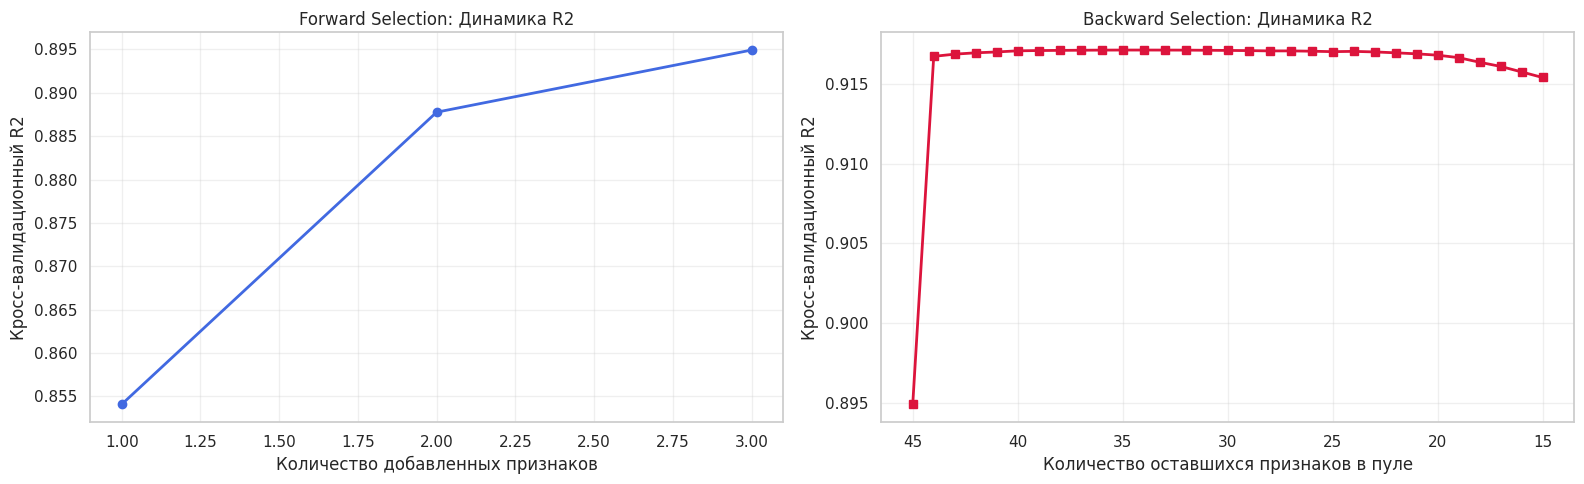


Обучение финальной модели Gradient Boosting (LightGBM) для оценки важности...


/tmp/ipykernel_1609/3185836660.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=lgb_imp_df.head(20), palette='viridis')


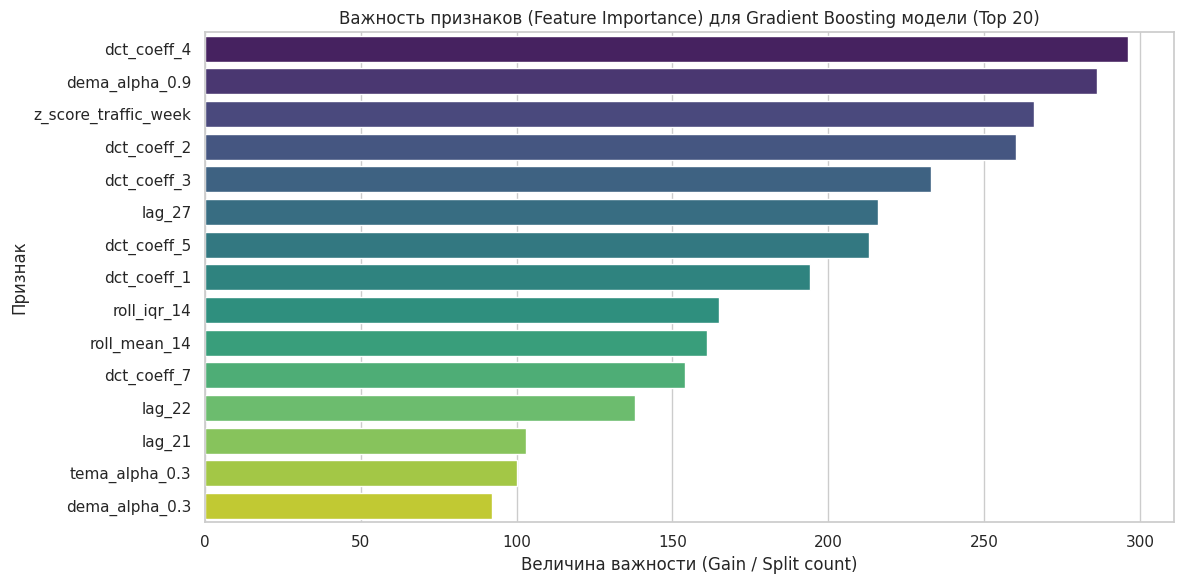

In [21]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#График для Forward Selection
axes[0].plot(range(1, len(forward_history) + 1), forward_history, marker='o', color='royalblue', linewidth=2)
axes[0].set_title("Forward Selection: Динамика R2")
axes[0].set_xlabel("Количество добавленных признаков")
axes[0].set_ylabel("Кросс-валидационный R2")
axes[0].grid(True, alpha=0.3)

# График для Backward Selection
total_start_features = 45
features_counts = [total_start_features - i for i in range(len(backward_history))]

axes[1].plot(features_counts, backward_history, marker='s', color='crimson', linewidth=2)
axes[1].set_title("Backward Selection: Динамика R2")
axes[1].set_xlabel("Количество оставшихся признаков в пуле")
axes[1].set_ylabel("Кросс-валидационный R2")
axes[1].invert_xaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nОбучение финальной модели Gradient Boosting (LightGBM) для оценки важности...")

X_final = df_cleaned[backward_selected_features].copy()
y_final = df_cleaned["target"].copy()

lgb_model = lgb.LGBMRegressor(n_estimators=100, max_depth=6, random_state=42, verbose=-1)
lgb_model.fit(X_final, y_final)

lgb_importances = lgb_model.feature_importances_
lgb_imp_df = pd.DataFrame({
    'feature': backward_selected_features,
    'importance': lgb_importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=lgb_imp_df.head(20), palette='viridis')
plt.title("Важность признаков (Feature Importance) для Gradient Boosting модели (Top 20)")
plt.xlabel("Величина важности (Gain / Split count)")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

In [22]:
target_col = 'target'
final_features = backward_selected_features.copy()

X_final = df_cleaned[final_features]
y_final = df_cleaned[target_col]

print(f"Количество признаков для обучения: {X_final.shape[1]}")
print(f"Размер матрицы признаков: {X_final.shape}")
print(f"Размер вектора ответов: {y_final.shape}")


Количество признаков для обучения: 15
Размер матрицы признаков: (14394, 15)
Размер вектора ответов: (14394,)


In [23]:
#Базовые параметры разделения на основе фич от Backward Selection
X_m = df_cleaned[backward_selected_features].copy()
y_m = df_cleaned['target'].copy()

total_len = len(df_cleaned)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

#Разбиение на матрицы
X_train, y_train = X_m.iloc[:train_end], y_m.iloc[:train_end]
X_val, y_val = X_m.iloc[train_end:val_end], y_m.iloc[train_end:val_end]
X_test, y_test = X_m.iloc[val_end:], y_m.iloc[val_end:]

# Объединенный тренировочно-валидационный набор для GridSearchCV кросс-валидации
X_train_val = X_m.iloc[:val_end]
y_train_val = y_m.iloc[:val_end]

print(f"Обучающая (Train):      {X_train.shape[0]} строк")
print(f"Валидационная (Val):    {X_val.shape[0]} строк")
print(f"Тестовая (Test):        {X_test.shape[0]} строк")

Обучающая (Train):      10075 строк
Валидационная (Val):    2159 строк
Тестовая (Test):        2160 строк


In [24]:
def evaluate_and_visualize_model(model_name, y_true, y_pred, index, save_dir, history=None):
    """
    Единая функция для расчета метрик
    """

    os.makedirs(save_dir, exist_ok=True)
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    if isinstance(index, (pd.Index, pd.Series)):
        index_arr = index.values
    else:
        index_arr = np.array(index)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    smape = np.mean(np.abs(y_true - y_pred) / (smape_denom + epsilon)) * 100
    r2 = r2_score(y_true, y_pred)

    metrics_df = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "MAPE (%)", "SMAPE (%)", "R2"],
        "Value": [mae, rmse, mape, smape, r2]
    })
    metrics_df.to_csv(os.path.join(save_dir, f"{model_name}_metrics.csv"), index=False)

    print(f"\nМетрики качества для {model_name}")
    print(metrics_df.to_string(index=False))

    residuals = y_true - y_pred
    abs_residuals = np.abs(residuals)
    error_threshold = np.percentile(abs_residuals, 95)
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(15, 6))
    plt.plot(index_arr, y_true, label="Фактические данные (Actual)", color="#1f77b4", alpha=0.75, lw=1.5)
    plt.plot(index_arr, y_pred, label="Предсказание (Predicted)", color="#ff7f0e", alpha=0.85, lw=1.5, linestyle="--")

    tem_df = pd.DataFrame({'index': index_arr, 'abs_err': abs_residuals})
    high_err_periods = tem_df[tem_df['abs_err'] >= error_threshold]

    legend_added = False
    for idx in high_err_periods['index']:
        plt.axvspan(idx, idx, color='red', alpha=0.1, label='Зона макс. ошибок' if not legend_added else "")
        legend_added = True

    plt.title(f"{model_name}: Фактические значения vs Предсказания\n", fontsize=14, fontweight='bold')
    plt.xlabel("Временной индекс", fontsize=12)
    plt.ylabel("Значение трафика", fontsize=12)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_predictions_vs_actuals.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.plot(index_arr, residuals, color="#d62728", alpha=0.8, lw=1)
    plt.axhline(0, color="black", linestyle="--", alpha=0.6)
    plt.title(f"{model_name}: Временной график ошибок предсказания (Остатки)", fontsize=14, fontweight='bold')
    plt.xlabel("Временной индекс", fontsize=12)
    plt.ylabel("Ошибка (Y_true - Y_pred)", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_residuals_time_series.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.histplot(residuals, kde=True, color="#2ca02c", bins=50, edgecolor='black')
    plt.axvline(0, color="red", linestyle="--", alpha=0.7, label="Идеальный ноль")
    plt.title(f"{model_name}: Распределение остатков модели", fontsize=14, fontweight='bold')
    plt.xlabel("Величина ошибки", fontsize=12)
    plt.ylabel("Плотность / Частота", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_residuals_distribution.png"), dpi=200)
    plt.show()

    if history is not None:
        plt.figure(figsize=(10, 5))
        if hasattr(history, 'history'):
            hist_dict = history.history
        else:
            hist_dict = history

        if 'loss' in hist_dict:
            plt.plot(hist_dict['loss'], label='Train Loss', color='#1f77b4', lw=2)
        if 'val_loss' in hist_dict:
            plt.plot(hist_dict['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
        plt.title(f"{model_name}: Кривые обучения (Learning Curves)", fontsize=14, fontweight='bold')
        plt.xlabel("Эпоха обучения", fontsize=12)
        plt.ylabel("Функция потерь (Loss)", fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_learning_curves.png"), dpi=200)
        plt.show()

    return metrics_df

In [25]:
import random
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Ridge Regression
Лучший параметр регуляризации alpha: 0.01

Метрики качества для Ridge_Regression
   Metric    Value
      MAE 4.073170
     RMSE 5.794506
 MAPE (%) 6.211510
SMAPE (%) 6.199354
       R2 0.945500


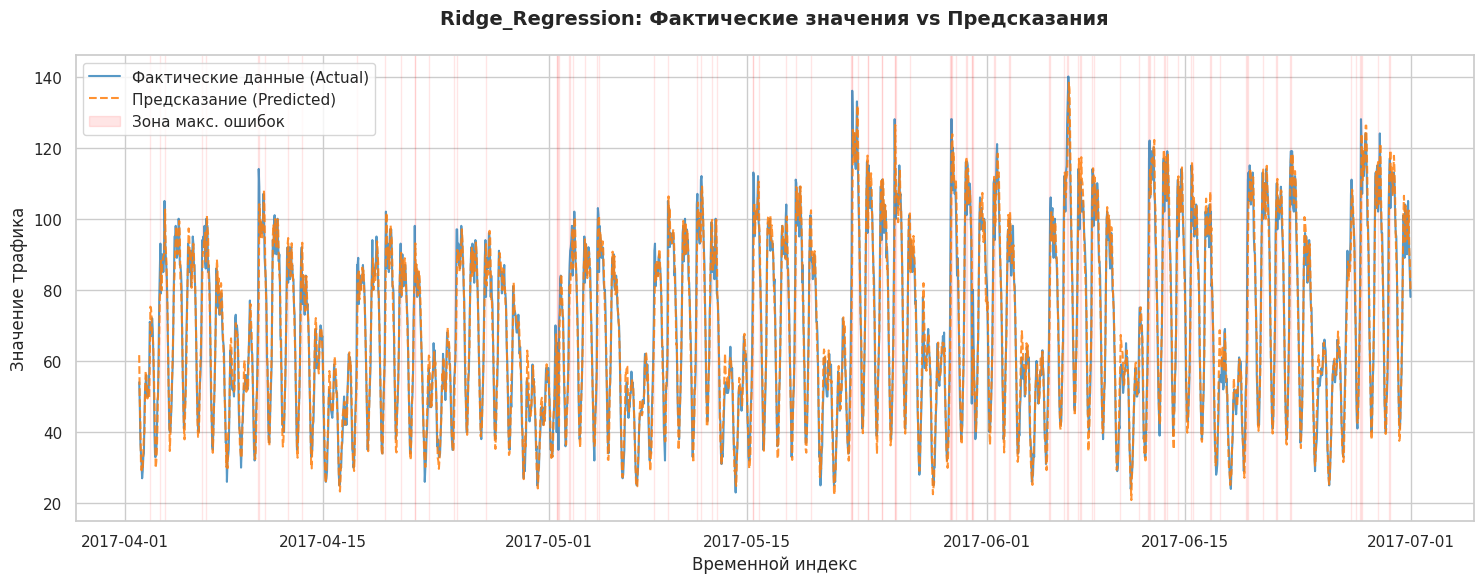

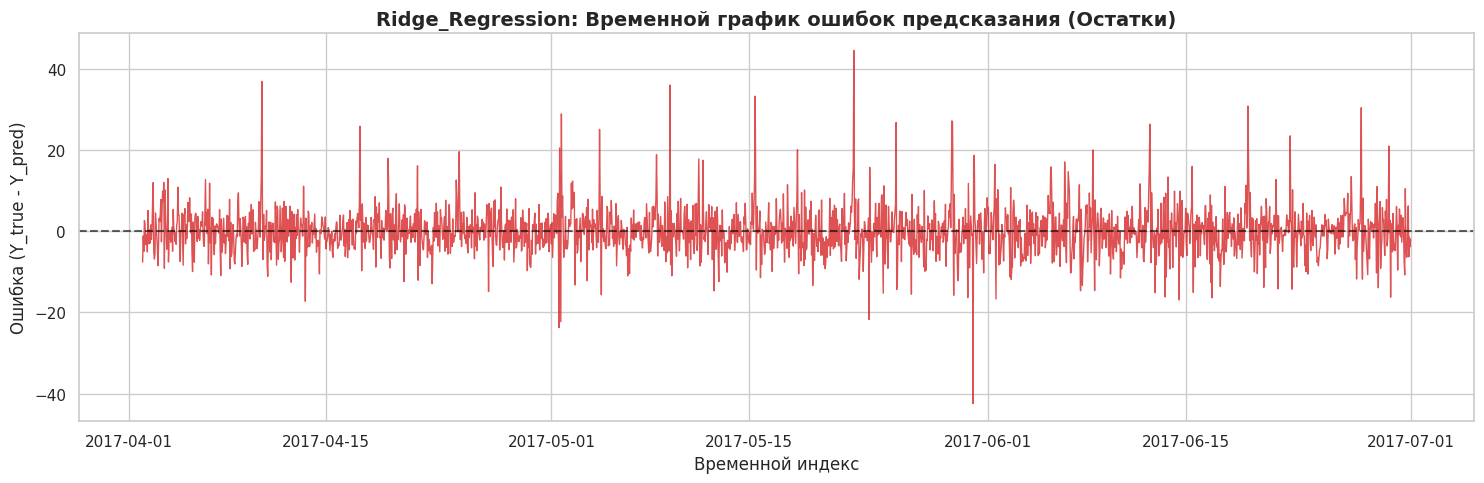

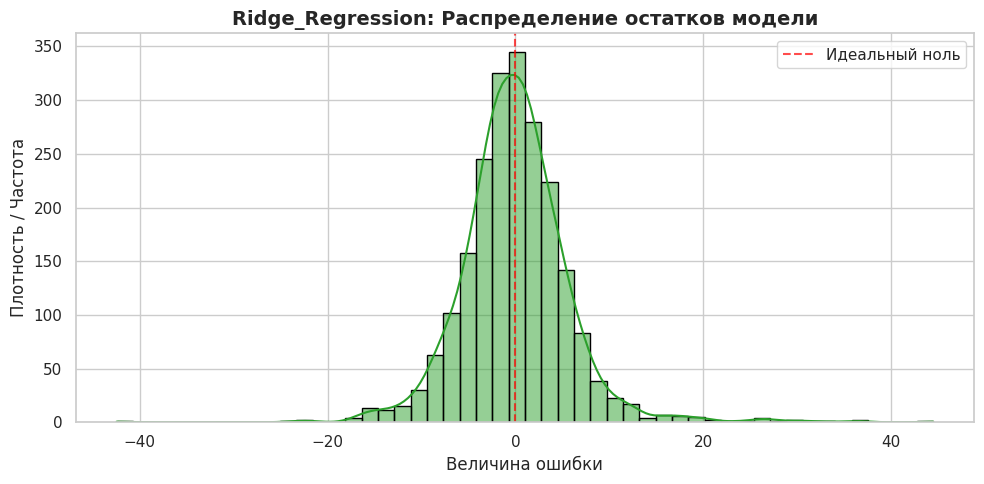

In [26]:
print("Ridge Regression")

#Настройки кросс-валидации для временных рядов
tscv = TimeSeriesSplit(n_splits=5)
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(), param_grid=ridge_params, cv=tscv, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_val, y_train_val)

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр регуляризации alpha: {ridge_grid.best_params_['alpha']}")

ridge_preds = best_ridge.predict(X_test)
ridge_metrics = evaluate_and_visualize_model(
    model_name="Ridge_Regression",
    y_true=y_test,
    y_pred=ridge_preds,
    index=X_test.index,
    save_dir="./model_results/ridge/"
)

LightGBM Regressor
Лучшие параметры LightGBM {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}. Валидационный R2: 0.8916

Метрики качества для LightGBM_Boosting
   Metric     Value
      MAE  7.859045
     RMSE 11.801764
 MAPE (%)  9.873960
SMAPE (%) 10.452473
       R2  0.773923


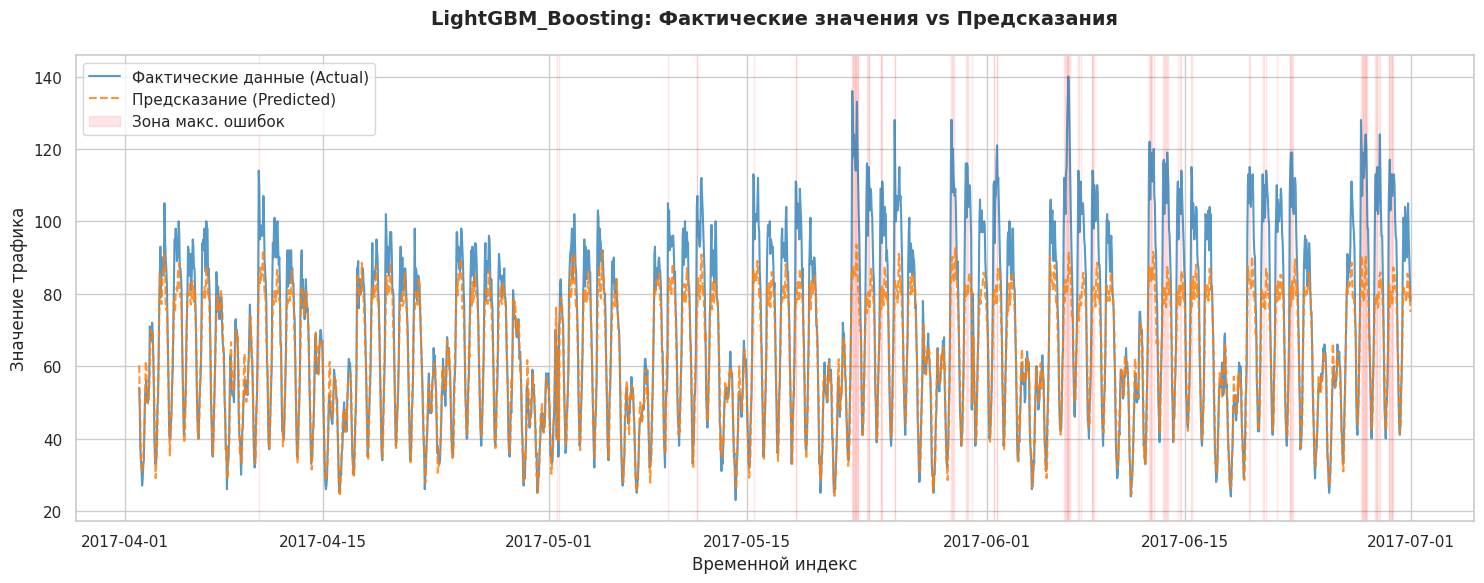

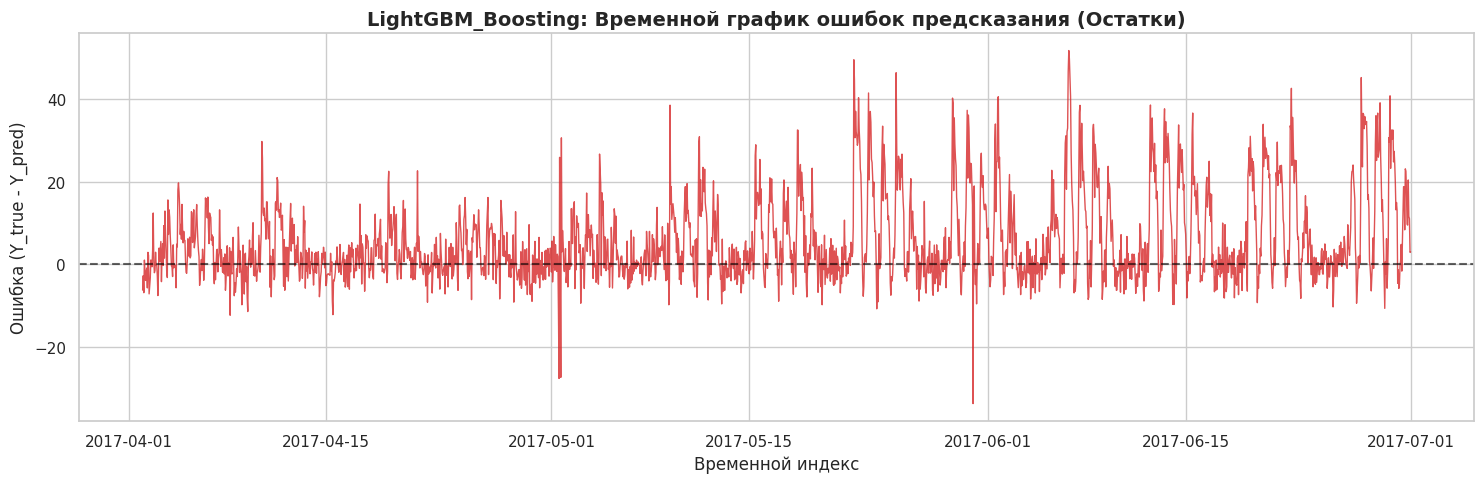

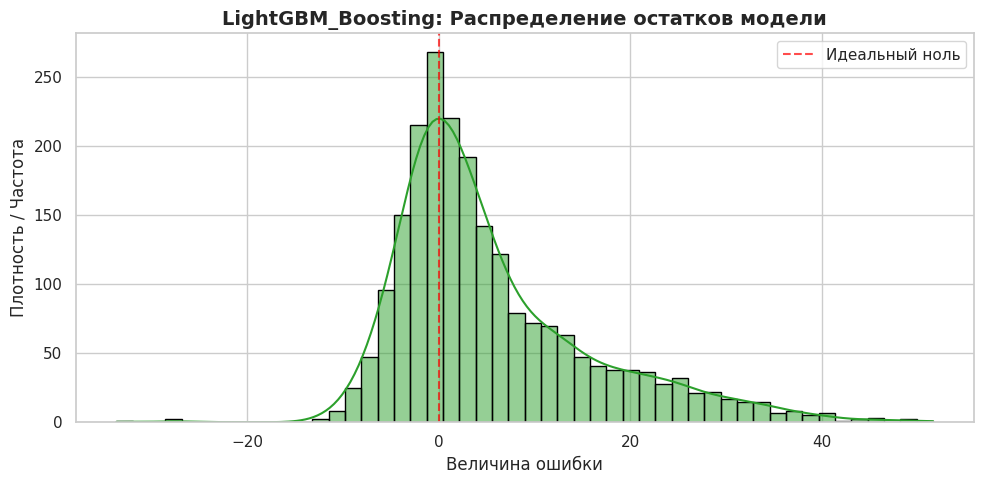

In [27]:
print("LightGBM Regressor")

lgb_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

best_lgb_score = -np.inf
best_lgb_model = None
best_params = None

for params in ParameterGrid(lgb_grid):
    model = lgb.LGBMRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    val_preds = model.predict(X_val)
    score = r2_score(y_val, val_preds)

    if score > best_lgb_score:
        best_lgb_score = score
        best_lgb_model = model
        best_params = params

print(f"Лучшие параметры LightGBM {best_params}. Валидационный R2: {best_lgb_score:.4f}")

lgb_preds = best_lgb_model.predict(X_test)
lgb_metrics = evaluate_and_visualize_model(
    model_name="LightGBM_Boosting",
    y_true=y_test,
    y_pred=lgb_preds,
    index=X_test.index,
    save_dir="./model_results/lightgbm/"
)

обучение LSTM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[01/36] Сетка: seq=10 | batch=16 | lr=0.001 -> Вал R2: 0.8780


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[02/36] Сетка: seq=20 | batch=16 | lr=0.001 -> Вал R2: 0.8722


...

[34/36] Сетка: seq=20 | batch=64 | lr=0.1   -> Вал R2: -1.3606


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[35/36] Сетка: seq=30 | batch=64 | lr=0.1   -> Вал R2: 0.6801


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[36/36] Сетка: seq=50 | batch=64 | lr=0.1   -> Вал R2: 0.8266
Лучшие параметры: {'batch_size': 16, 'lr': 0.001, 'seq_length': 50} с Валидационным R2 = 0.8925

Метрики качества для LSTM_Neural_Network
   Metric    Value
      MAE 5.107025
     RMSE 7.159163
 MAPE (%) 7.670630
SMAPE (%) 7.758630
       R2 0.916807


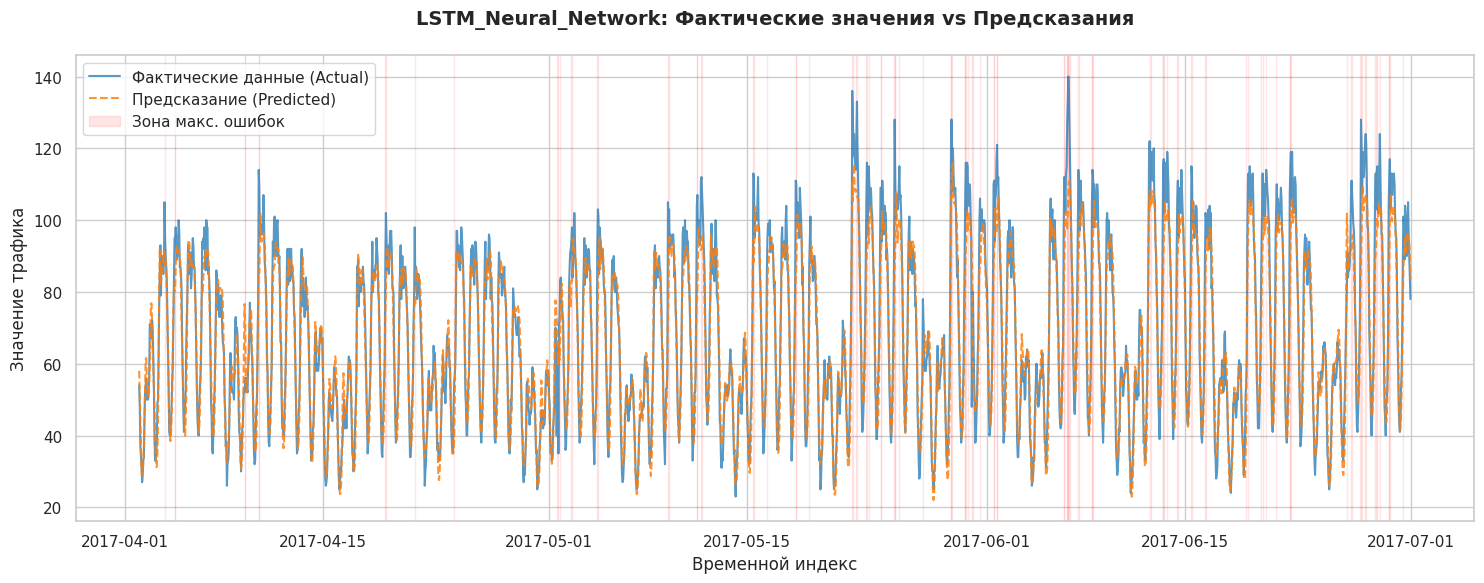

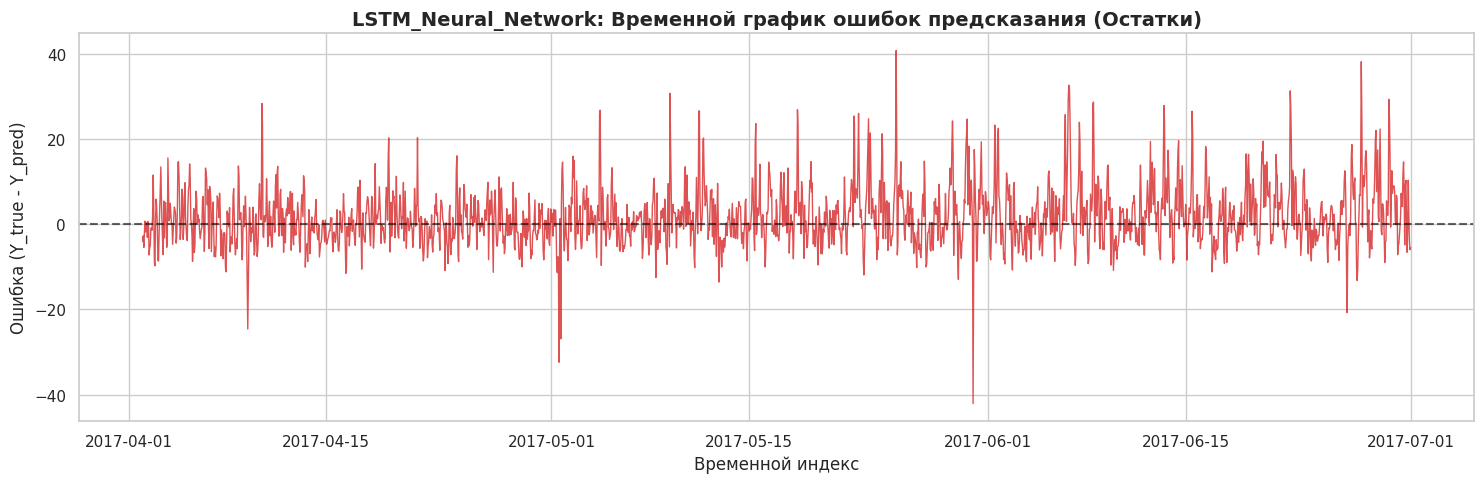

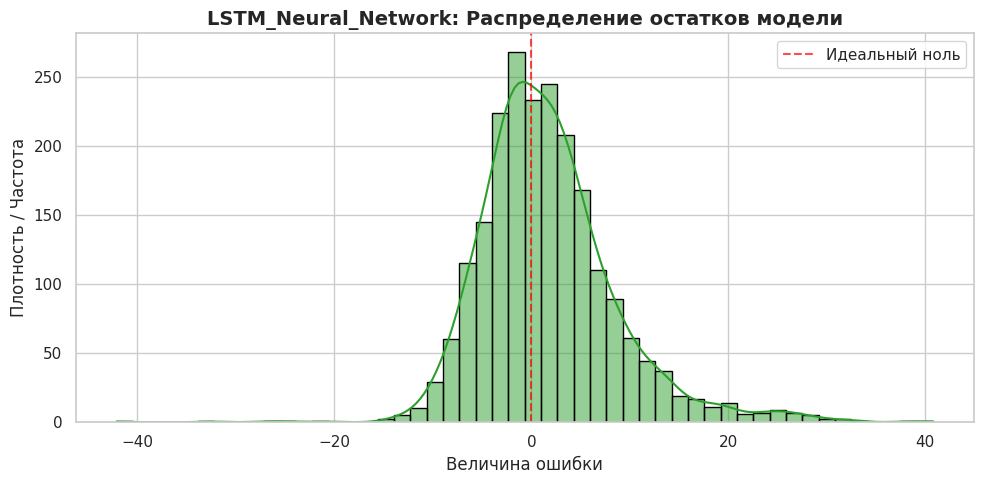

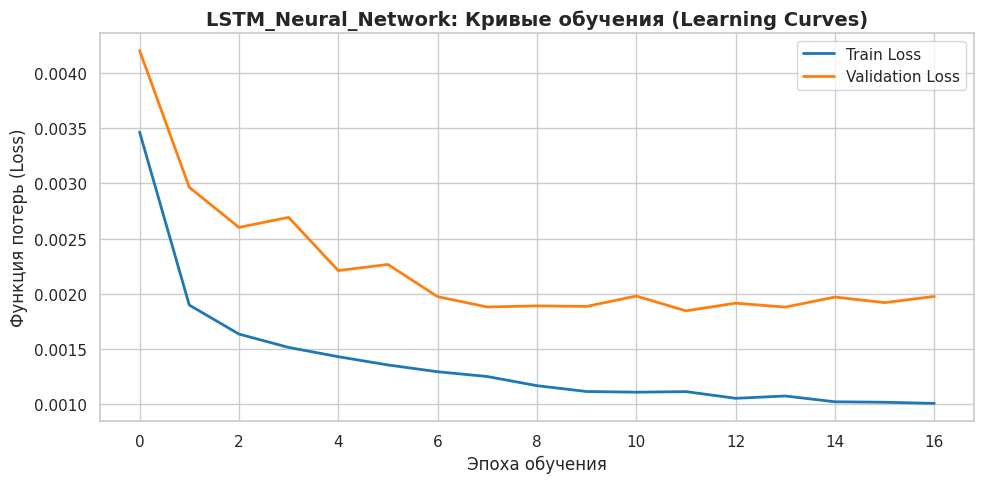

In [28]:
print("обучение LSTM")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_m_scaled = scaler_X.fit_transform(X_m)
y_m_scaled = scaler_y.fit_transform(y_m.values.reshape(-1, 1))

def create_sequences(X_data, y_data, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - seq_length):
        X_seq.append(X_data[i : i + seq_length])
        y_seq.append(y_data[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

full_grid = {
    'seq_length': [10, 20, 30, 50],
    'batch_size': [16, 32, 64],
    'lr': [0.001, 0.01, 0.1]
}
lstm_param_grid = list(ParameterGrid(full_grid))

best_lstm_score = -np.inf
best_lstm_model = None
best_lstm_history = None
best_params = None
best_seq_length = None

for idx, params in enumerate(lstm_param_grid, 1):
    seq_len = params['seq_length']

    X_seq, y_seq = create_sequences(X_m_scaled, y_m_scaled, seq_len)
    train_end_seq = train_end - seq_len
    val_end_seq = val_end - seq_len

    X_train_l, y_train_l = X_seq[:train_end_seq], y_seq[:train_end_seq]
    X_val_l, y_val_l = X_seq[train_end_seq:val_end_seq], y_seq[train_end_seq:val_end_seq]

    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(80, return_sequences=True, input_shape=(X_train_l.shape[1], X_train_l.shape[2])),
        Dropout(0.2),
        LSTM(40, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=params['lr'])
    model.compile(optimizer=optimizer, loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_l, y_train_l,
        validation_data=(X_val_l, y_val_l),
        epochs=30,
        batch_size=params['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )

    val_preds_scaled = model.predict(X_val_l, verbose=0)
    score = r2_score(y_val_l, val_preds_scaled)
    print(f"[{idx:02d}/{len(lstm_param_grid)}] Сетка: seq={seq_len:<2} | batch={params['batch_size']:<2} | lr={params['lr']:<5} -> Вал R2: {score:.4f}")

    if score > best_lstm_score:
        best_lstm_score = score
        best_lstm_model = model
        best_lstm_history = history
        best_params = params
        best_seq_length = seq_len

print(f"Лучшие параметры: {best_params} с Валидационным R2 = {best_lstm_score:.4f}")

X_seq_final, y_seq_final = create_sequences(X_m_scaled, y_m_scaled, best_seq_length)
val_end_seq_final = val_end - best_seq_length

X_test_lstm = X_seq_final[val_end_seq_final:]
y_test_lstm = y_seq_final[val_end_seq_final:]

lstm_preds_scaled = best_lstm_model.predict(X_test_lstm, verbose=0)

lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled)
y_test_true_unscaled = scaler_y.inverse_transform(y_test_lstm)

test_index_lstm = X_test.index

lstm_metrics = evaluate_and_visualize_model(
    model_name="LSTM_Neural_Network",
    y_true=y_test_true_unscaled,
    y_pred=lstm_preds,
    index=test_index_lstm,
    save_dir="./model_results/lstm/",
    history=best_lstm_history
)


Сводная таблица метрик качества:


,Metric,Ridge_Regression,LightGBM_Boosting,LSTM_Neural_Network
0,MAE,4.073170,7.859045,5.107025
1,RMSE,5.794506,11.801764,7.159163
2,MAPE (%),6.211510,9.873960,7.670630
3,SMAPE (%),6.199354,10.452473,7.758630
4,R2,0.945500,0.773923,0.916807



 Лучшая модель по метрике R2: Ridge_Regression (R2 = 0.9455)


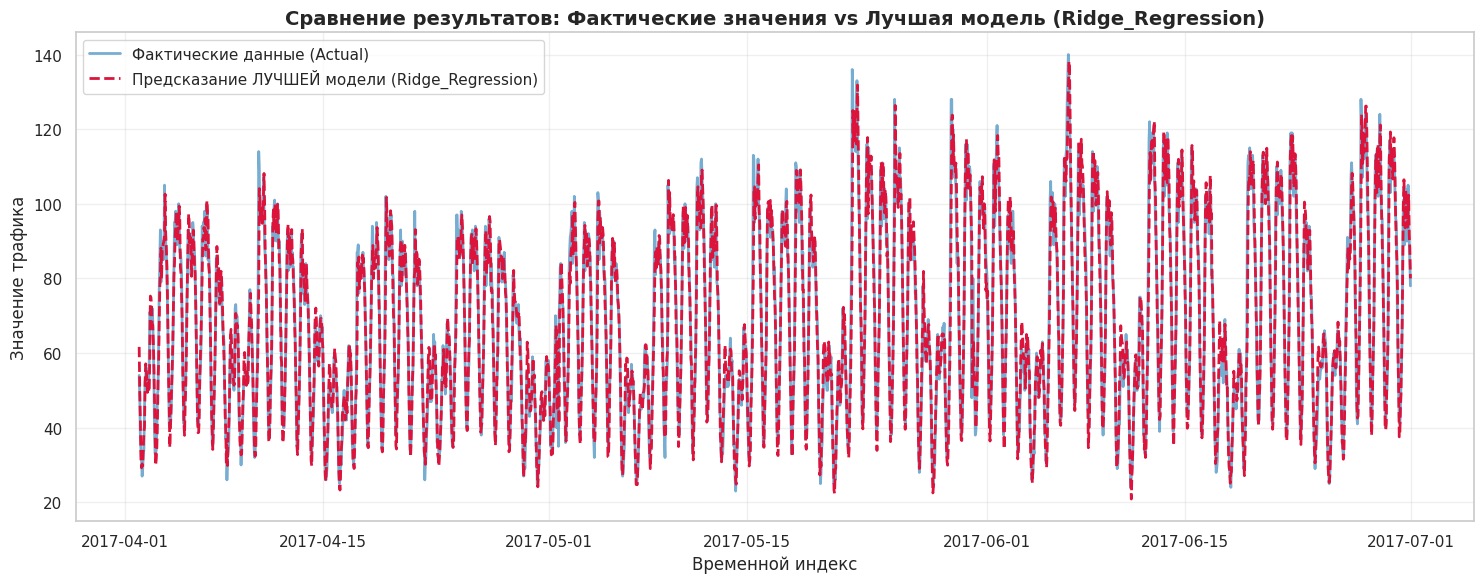

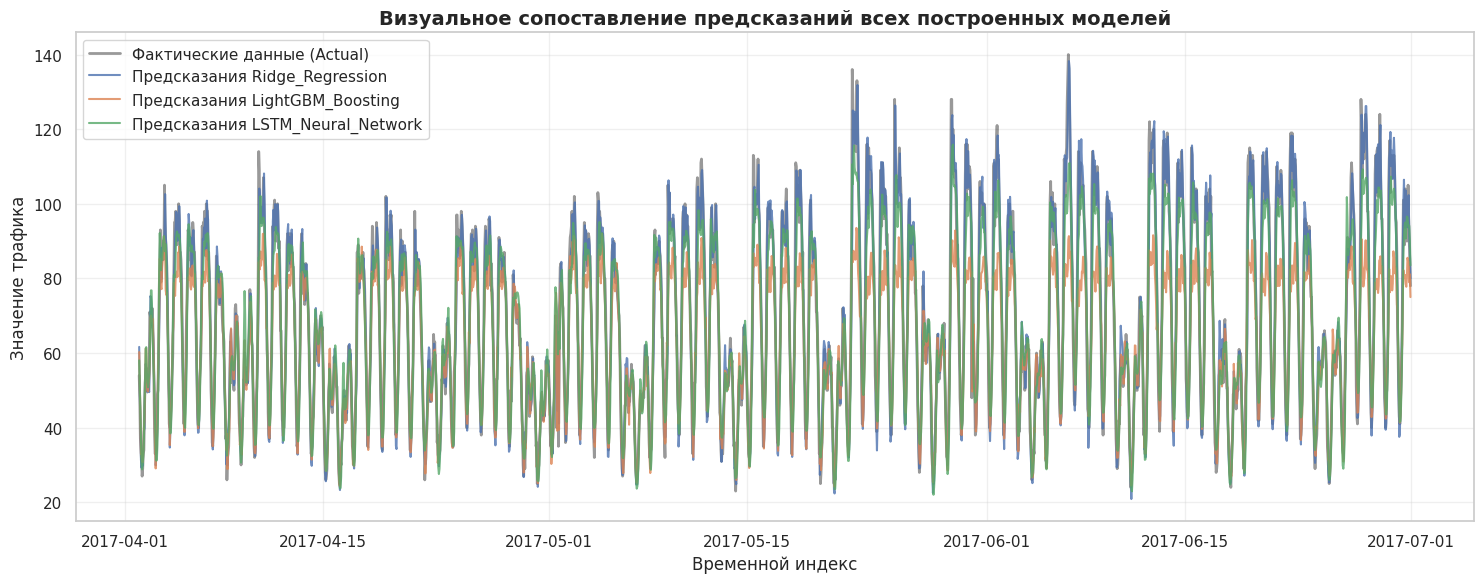

In [29]:
df1 = ridge_metrics.rename(columns={"Value": "Ridge_Regression"})
df2 = lgb_metrics.rename(columns={"Value": "LightGBM_Boosting"})
df3 = lstm_metrics.rename(columns={"Value": "LSTM_Neural_Network"})

summary_metrics = df1.merge(df2, on="Metric").merge(df3, on="Metric")

print("\nСводная таблица метрик качества:")
display(summary_metrics)

summary_metrics.to_csv("./model_results/summary_models_comparison.csv", index=False)

r2_scores = {
    "Ridge_Regression": summary_metrics.loc[summary_metrics["Metric"] == "R2", "Ridge_Regression"].values[0],
    "LightGBM_Boosting": summary_metrics.loc[summary_metrics["Metric"] == "R2", "LightGBM_Boosting"].values[0],
    "LSTM_Neural_Network": summary_metrics.loc[summary_metrics["Metric"] == "R2", "LSTM_Neural_Network"].values[0]
}

best_model_name = max(r2_scores, key=r2_scores.get)
print(f"\n Лучшая модель по метрике R2: {best_model_name} (R2 = {r2_scores[best_model_name]:.4f})")

predictions_dict = {
    "Ridge_Regression": ridge_preds,
    "LightGBM_Boosting": lgb_preds,
    "LSTM_Neural_Network": lstm_preds
}


actual_lstm_len = len(y_test_true_unscaled)
aligned_index = X_test.index[-actual_lstm_len:]
y_true_plot = y_test_true_unscaled.flatten()
best_pred_plot = np.array(predictions_dict[best_model_name]).flatten()[-actual_lstm_len:]
plt.figure(figsize=(15, 6))
plt.plot(aligned_index, y_true_plot, label="Фактические данные (Actual)", color="#1f77b4", alpha=0.6, lw=2)
plt.plot(aligned_index, best_pred_plot, label=f"Предсказание ЛУЧШЕЙ модели ({best_model_name})", color="crimson", lw=2, linestyle="--")

plt.title(f"Сравнение результатов: Фактические значения vs Лучшая модель ({best_model_name})", fontsize=14, fontweight='bold')
plt.xlabel("Временной индекс", fontsize=12)
plt.ylabel("Значение трафика", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./model_results/best_model_predictions_vs_actual.png", dpi=200)
plt.show()


plt.figure(figsize=(15, 6))
plt.plot(aligned_index, y_true_plot, label="Фактические данные (Actual)", color="black", alpha=0.4, lw=2)

for model_key, preds_array in predictions_dict.items():
    plot_preds = np.array(preds_array).flatten()[-actual_lstm_len:]
    plt.plot(aligned_index, plot_preds, label=f"Предсказания {model_key}", alpha=0.8, lw=1.5)

plt.title("Визуальное сопоставление предсказаний всех построенных моделей", fontsize=14, fontweight='bold')
plt.xlabel("Временной индекс", fontsize=12)
plt.ylabel("Значение трафика", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./model_results/all_models_comparison_plot.png", dpi=200)
plt.show()

Анализ ошибок лучшей модели
Порог для топ-5% наибольших ошибок: 11.07 машин
Количество зафиксированных проблемных часов: 108
 -> Среднее значение ошибки (смещение): -0.0279 (идеально около 0)
 -> Стандартное отклонение ошибки: 5.7944

Топ-10 периодов (часов) с максимальными абсолютными ошибками:


,Actual,Predicted,Residual,Abs_Error
DateTime,,,,
2017-05-22 11:00:00,136,91.526090,44.473910,44.473910
2017-05-30 22:00:00,48,90.458855,-42.458855,42.458855
2017-04-10 11:00:00,114,77.105249,36.894751,36.894751
2017-05-09 10:00:00,105,69.008856,35.991144,35.991144
2017-05-15 11:00:00,113,79.756941,33.243059,33.243059
2017-06-19 10:00:00,96,65.196989,30.803011,30.803011
2017-06-27 11:00:00,128,97.580822,30.419178,30.419178
2017-05-01 17:00:00,70,41.130643,28.869357,28.869357
2017-05-29 10:00:00,102,74.847802,27.152198,27.152198


/tmp/ipykernel_1609/67159720.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_error_df['hour'] = high_error_df.index.hour


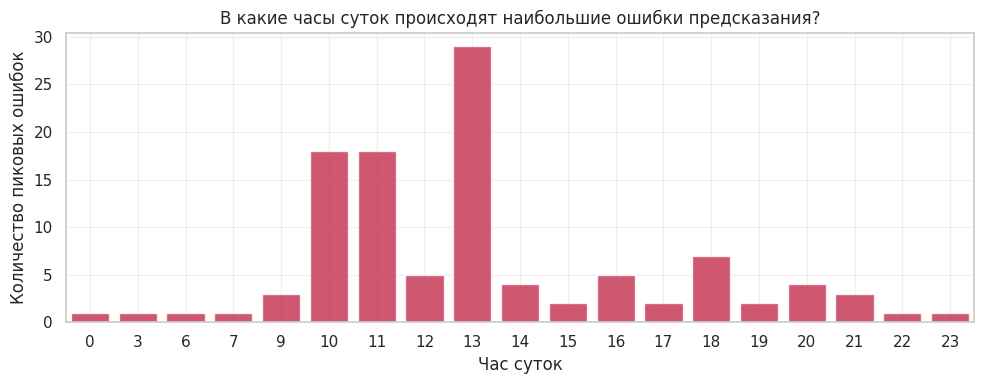

In [30]:
print("Анализ ошибок лучшей модели")

ridge_residuals = y_test - ridge_preds
ridge_abs_residuals = np.abs(ridge_residuals)

error_threshold = np.percentile(ridge_abs_residuals, 95)

error_analysis_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': ridge_preds,
    'Residual': ridge_residuals,
    'Abs_Error': ridge_abs_residuals
}, index=X_test.index)

high_error_df = error_analysis_df[error_analysis_df['Abs_Error'] >= error_threshold]

print(f"Порог для топ-5% наибольших ошибок: {error_threshold:.2f} машин")
print(f"Количество зафиксированных проблемных часов: {len(high_error_df)}")

mean_res = np.mean(ridge_residuals)
std_res = np.std(ridge_residuals)

print(f" -> Среднее значение ошибки (смещение): {mean_res:.4f} (идеально около 0)")
print(f" -> Стандартное отклонение ошибки: {std_res:.4f}")

print("\nТоп-10 периодов (часов) с максимальными абсолютными ошибками:")
top_10_errors = high_error_df.sort_values(by='Abs_Error', ascending=False).head(10)

display(top_10_errors[['Actual', 'Predicted', 'Residual', 'Abs_Error']])

high_error_df['hour'] = high_error_df.index.hour
tem_hours = high_error_df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=tem_hours.index, y=tem_hours.values, color='crimson', alpha=0.8)
plt.title("В какие часы суток происходят наибольшие ошибки предсказания?")
plt.xlabel("Час суток")
plt.ylabel("Количество пиковых ошибок")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
import shutil
from google.colab import files

shutil.make_archive('all_model_results', 'zip', './model_results')
print("Архив 'all_model_results.zip' успешно создан!")
files.download('all_model_results.zip')

Архив 'all_model_results.zip' успешно создан!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>